## 1 · Environment Setup

In [5]:
!pip install -q torch torchvision pandas pillow tqdm

In [6]:
import os
import re
import math
import random
import string
import pickle
from collections import Counter
from PIL import Image

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


## 2 · Mount Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR      = '/content/drive/MyDrive/caption_data'
SAVE_DIR      = os.path.join(BASE_DIR, 'trained')
os.makedirs(SAVE_DIR, exist_ok=True)

# Copy data to local disk for faster I/O
print("Copying data to local disk...")
!cp -r /content/drive/MyDrive/caption_data/Images /content/Images
!cp /content/drive/MyDrive/caption_data/captions.txt /content/captions.txt
print("Done.")

CAPTIONS_FILE = '/content/captions.txt'
IMAGES_DIR    = '/content/Images'

print(f'  captions : {CAPTIONS_FILE}')
print(f'  images   : {IMAGES_DIR}')
print(f'  save_dir : {SAVE_DIR}')

Mounted at /content/drive
Copying data to local disk...
Done.
  captions : /content/captions.txt
  images   : /content/Images
  save_dir : /content/drive/MyDrive/caption_data/trained


## 3 · Hyperparameters

In [8]:
MIN_WORD_FREQ = 2       # words appearing fewer times are mapped to <UNK>
TRAIN_SPLIT   = 0.80    # fraction of *images* used for training
IMG_SIZE      = 224

EMBED_DIM   = 256
HIDDEN_DIM  = 512
NUM_LAYERS  = 1
DROPOUT     = 0.5

BATCH_SIZE  = 64
NUM_EPOCHS  = 30
LR          = 3e-4
GRAD_CLIP   = 5.0
LR_PATIENCE = 3        # epochs of no val improvement before halving LR
LR_FACTOR   = 0.5
PATIENCE    = 5        # epochs of no val improvement before early stopping

PAD_TOKEN   = '<PAD>'
UNK_TOKEN   = '<UNK>'
START_TOKEN = '<START>'
END_TOKEN   = '<END>'

print('Hyperparameters loaded.')

Hyperparameters loaded.


## 4 · Data Loading & Text Cleaning

In [9]:
def load_captions(filepath: str) -> pd.DataFrame:
    """
    Read captions.txt.
    Expected format (Flickr8k style): each line is  'image_file,caption'
    or tab-separated.  The first column is the image filename.
    """
    rows = []
    with open(filepath, 'r', encoding='utf-8') as fh:
        for i, line in enumerate(fh):
            line = line.strip()
            if not line or line.lower().startswith('image'):
                continue  # skip header or blank lines
            # Support comma or tab as separator
            if '\t' in line:
                parts = line.split('\t', 1)
            else:
                parts = line.split(',', 1)
            if len(parts) != 2:
                continue
            image_name, caption = parts[0].strip(), parts[1].strip()
            # Some Flickr8k files append '#N' to the filename  (e.g. dog.jpg#0)
            image_name = image_name.split('#')[0]
            rows.append({'image': image_name, 'caption': caption})
    df = pd.DataFrame(rows)
    print(f'Loaded {len(df):,} caption rows for {df["image"].nunique():,} unique images.')
    return df


df_raw = load_captions(CAPTIONS_FILE)
df_raw.head()

Loaded 40,455 caption rows for 8,091 unique images.


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [10]:
ARTICLES = {'a', 'an', 'the'}


def clean_caption(text: str) -> str:
    """Lowercase, remove punctuation & digits, strip articles and 1-char words."""
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Tokenise on whitespace
    tokens = text.split()
    # Drop single-character tokens and articles
    tokens = [t for t in tokens if len(t) > 1 and t not in ARTICLES]
    # Wrap with START / END
    tokens = [START_TOKEN] + tokens + [END_TOKEN]
    return ' '.join(tokens)


df = df_raw.copy()
df['caption'] = df['caption'].apply(clean_caption)

print('Sample cleaned captions:')
for _, row in df.head(3).iterrows():
    print(f'  {row["image"]}  →  {row["caption"]}')

Sample cleaned captions:
  1000268201_693b08cb0e.jpg  →  <START> child in pink dress is climbing up set of stairs in entry way <END>
  1000268201_693b08cb0e.jpg  →  <START> girl going into wooden building <END>
  1000268201_693b08cb0e.jpg  →  <START> little girl climbing into wooden playhouse <END>


## 5 · Vocabulary

In [11]:
class Vocabulary:
    """Word ↔ index mapping with frequency-based filtering."""

    def __init__(self, min_freq: int = 5):
        self.min_freq = min_freq
        # Reserve indices for special tokens
        self.word2idx = {
            PAD_TOKEN: 0,
            UNK_TOKEN: 1,
            START_TOKEN: 2,
            END_TOKEN: 3,
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self._counter: Counter = Counter()

    # Special token indices (properties for convenience)
    @property
    def pad_idx(self):   return self.word2idx[PAD_TOKEN]
    @property
    def unk_idx(self):   return self.word2idx[UNK_TOKEN]
    @property
    def start_idx(self): return self.word2idx[START_TOKEN]
    @property
    def end_idx(self):   return self.word2idx[END_TOKEN]

    def __len__(self):
        return len(self.word2idx)

    def build(self, captions: pd.Series) -> None:
        """Count all words in *captions* and add those above min_freq."""
        for caption in captions:
            for word in caption.split():
                if word not in (PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN):
                    self._counter[word] += 1
        for word, freq in self._counter.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
        print(f'Vocabulary built: {len(self):,} tokens  '
              f'(min_freq={self.min_freq}, '
              f'rare_words_collapsed_to_UNK: '
              f'{sum(1 for f in self._counter.values() if f < self.min_freq):,})')

    def numericalize(self, sentence: str) -> list[int]:
        """Convert a whitespace-tokenised string to a list of indices."""
        return [
            self.word2idx.get(word, self.unk_idx)
            for word in sentence.split()
        ]

    def decode(self, indices: list[int], skip_special: bool = True) -> str:
        """Convert indices back to a human-readable string."""
        special = {self.pad_idx, self.start_idx, self.end_idx}
        words = []
        for idx in indices:
            if skip_special and idx in special:
                if idx == self.end_idx:
                    break
                continue
            words.append(self.idx2word.get(idx, UNK_TOKEN))
        return ' '.join(words)


# Build vocabulary from ALL captions (train + val share the same vocab)
vocab = Vocabulary(min_freq=MIN_WORD_FREQ)
vocab.build(df['caption'])

print(f'\nVocabulary size : {len(vocab)}')
print(f'PAD idx         : {vocab.pad_idx}')
print(f'START idx       : {vocab.start_idx}')
print(f'END idx         : {vocab.end_idx}')

Vocabulary built: 5,191 tokens  (min_freq=2, rare_words_collapsed_to_UNK: 3,576)

Vocabulary size : 5191
PAD idx         : 0
START idx       : 2
END idx         : 3


## 6 · Train / Validation Split (by Image)

In [12]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

n_train    = int(len(all_images) * TRAIN_SPLIT)
train_imgs = set(all_images[:n_train])
val_imgs   = set(all_images[n_train:])

df_train = df[df['image'].isin(train_imgs)].reset_index(drop=True)
df_val   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f'Train: {len(train_imgs):,} images  ({len(df_train):,} captions)')
print(f'Val  : {len(val_imgs):,} images  ({len(df_val):,} captions)')

# Sanity-check: no image appears in both splits
assert train_imgs.isdisjoint(val_imgs), 'Leak detected!'
print('No image leakage between splits. ✓')

Train: 6,472 images  (32,360 captions)
Val  : 1,619 images  (8,095 captions)
No image leakage between splits. ✓


## 7 · Dataset & DataLoader

In [13]:
# ImageNet normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms defined.')

Transforms defined.


In [14]:
class CaptionDataset(Dataset):
    """
    Returns (image_tensor, caption_indices) pairs.
    Each (image, caption) row in the DataFrame becomes one sample.
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        images_dir: str,
        vocabulary: Vocabulary,
        transform=None,
    ):
        self.df         = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.vocab      = vocabulary
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row     = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])

        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except (FileNotFoundError, OSError):
            # Return a blank image if file is missing (graceful degradation)
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))

        if self.transform:
            image = self.transform(image)

        # Numericalize caption
        caption_ids = torch.tensor(
            self.vocab.numericalize(row['caption']),
            dtype=torch.long,
        )
        return image, caption_ids


def collate_fn(batch, pad_idx: int):
    """
    Pads variable-length caption sequences to the length of the longest
    caption in the batch.  Returns (images, captions) tensors.
    """
    images, captions = zip(*batch)

    # Stack images  →  (B, C, H, W)
    images = torch.stack(images, dim=0)

    # Pad captions  →  (B, T_max)
    captions = torch.nn.utils.rnn.pad_sequence(
        captions,
        batch_first=True,
        padding_value=pad_idx,
    )
    return images, captions


import functools

train_dataset = CaptionDataset(df_train, IMAGES_DIR, vocab, train_transform)
val_dataset   = CaptionDataset(df_val,   IMAGES_DIR, vocab, val_transform)

_collate = functools.partial(collate_fn, pad_idx=vocab.pad_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(DEVICE.type == 'cuda'),
    collate_fn=_collate,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=(DEVICE.type == 'cuda'),
    collate_fn=_collate,
)

print(f'Train batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')

# Quick smoke-test
sample_imgs, sample_caps = next(iter(train_loader))
print(f'\nSample batch — images: {tuple(sample_imgs.shape)}, '
      f'captions: {tuple(sample_caps.shape)}')

Train batches : 506
Val batches   : 127


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Sample batch — images: (64, 3, 224, 224), captions: (64, 17)


## 8 · Model Architecture

In [15]:
import torch.nn.functional as F

class EncoderCNN(nn.Module):
    def __init__(self, embed_dim: int):
        super().__init__()
        # Using ResNet50 for better feature extraction
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Remove the global pooling and FC layer to keep the spatial grid (7x7)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        # Projection layer to match the hidden dim of the decoder
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # Freeze early layers, but keep later layers trainable for fine-tuning
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Unfreeze the last two blocks of ResNet (Layer 3 and 4)
        for param in list(self.resnet.parameters())[-20:]:
            param.requires_grad = True

    def forward(self, images):
        # images: (B, 3, 224, 224)
        features = self.resnet(images)  # (B, 2048, 7, 7)
        features = features.permute(0, 2, 3, 1)  # (B, 7, 7, 2048)
        features = features.view(features.size(0), -1, features.size(-1)) # (B, 49, 2048)
        return features

class Attention(nn.Module):
    """
    Bahdanau Attention mechanism.
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attention_dim = attention_dim
        self.W = nn.Linear(decoder_dim, attention_dim)
        self.U = nn.Linear(encoder_dim, attention_dim)
        self.A = nn.Linear(attention_dim, 1)

    def forward(self, features, hidden_state):
        # features: (B, 49, 2048), hidden_state: (B, hidden_dim)
        u_attn = self.U(features)   # (B, 49, attention_dim)
        w_attn = self.W(hidden_state).unsqueeze(1) # (B, 1, attention_dim)

        combined_attn = torch.tanh(u_attn + w_attn) # (B, 49, attention_dim)

        attention_scores = self.A(combined_attn).squeeze(2) # (B, 49)
        alpha = F.softmax(attention_scores, dim=1)          # (B, 49) - Weights

        attention_weighted_encoding = (features * alpha.unsqueeze(2)).sum(dim=1) # (B, 2048)
        return attention_weighted_encoding, alpha

class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, decoder_dim, encoder_dim, attention_dim, dropout=0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)

        # LSTMCell is used instead of LSTM for manual step-by-step decoding with attention
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)

        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.init_h = nn.Linear(encoder_dim, decoder_dim) # For initial hidden state
        self.init_c = nn.Linear(encoder_dim, decoder_dim) # For initial cell state

    def forward(self, features, captions):
        # features: (B, 49, 2048), captions: (B, max_len)
        embeddings = self.embedding(captions) # (B, max_len, embed_dim)

        # Initial states
        avg_features = features.mean(dim=1)
        h = self.init_h(avg_features)
        c = self.init_c(avg_features)

        batch_size = features.size(0)
        num_steps = captions.size(1) - 1 # We don't predict after <END>

        predictions = torch.zeros(batch_size, num_steps, self.vocab_size).to(features.device)

        for t in range(num_steps):
            # Calculate Attention
            attention_weighted_encoding, _ = self.attention(features, h)

            # Combine current word embedding and the visual context
            lstm_input = torch.cat([embeddings[:, t, :], attention_weighted_encoding], dim=1)

            h, c = self.decode_step(lstm_input, (h, c))
            preds = self.fc(self.dropout(h))
            predictions[:, t, :] = preds

        return predictions

    @torch.no_grad()
    def generate(self, features, vocab, max_len=20):
        batch_size = features.size(0)
        avg_features = features.mean(dim=1)
        h = self.init_h(avg_features)
        c = self.init_c(avg_features)

        word = torch.tensor([vocab.start_idx]).to(features.device)
        generated = []

        for _ in range(max_len):
            attention_weighted_encoding, _ = self.attention(features, h)
            embeddings = self.embedding(word)

            lstm_input = torch.cat([embeddings, attention_weighted_encoding], dim=1)
            h, c = self.decode_step(lstm_input, (h, c))

            output = self.fc(h)
            predicted_word_idx = output.argmax(1)

            if predicted_word_idx.item() == vocab.end_idx:
                break

            generated.append(predicted_word_idx.item())
            word = predicted_word_idx

        return generated

In [16]:
import torch.nn.functional as F

class ImageCaptioningModel(nn.Module):
    """
    Updated wrapper that composes EncoderCNN + DecoderWithAttention.
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim:  int = 256,
        hidden_dim: int = 512,
        attention_dim: int = 256,
        encoder_dim: int = 2048, # ResNet50 feature depth is 2048
        dropout:    float = 0.5,
    ):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim)
        self.decoder = DecoderWithAttention(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            decoder_dim=hidden_dim,
            encoder_dim=encoder_dim,
            attention_dim=attention_dim,
            dropout=dropout
        )

    def forward(self, images, captions):
        # images: (B, 3, 224, 224)
        # captions: (B, T)
        features = self.encoder(images)                # (B, 49, 2048)
        logits = self.decoder(features, captions)      # (B, T-1, vocab_size)
        return logits

    def caption_image(self, image, vocab, max_len=40):
        """Used for inference"""
        self.eval()
        with torch.no_grad():
            # image shape: (3, 224, 224) -> (1, 3, 224, 224)
            features = self.encoder(image.unsqueeze(0))
            indices = self.decoder.generate(features, vocab, max_len)
        return vocab.decode(indices)

# Instantiate the NEW model
# removed 'num_layers' because Attention uses LSTMCell (1 layer)
model = ImageCaptioningModel(
    vocab_size    = len(vocab),
    embed_dim     = EMBED_DIM,      # 256
    hidden_dim    = HIDDEN_DIM,     # 512
    attention_dim = 256,            # New param
    encoder_dim   = 2048,           # ResNet50 output size
    dropout       = DROPOUT,        # 0.5
).to(DEVICE)

# Parameter count check
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}  ({100*trainable_params/total_params:.1f} %)')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 77.4MB/s]


Total parameters     : 36,025,480
Trainable parameters : 21,446,728  (59.5 %)


## 9 · Training Setup

In [17]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
)

print('Loss   : CrossEntropyLoss  (pad_idx ignored)')
print('Optim  : Adam  lr={:.0e}'.format(LR))
print(f'Sched  : ReduceLROnPlateau  patience={LR_PATIENCE}  factor={LR_FACTOR}')

Loss   : CrossEntropyLoss  (pad_idx ignored)
Optim  : Adam  lr=3e-04
Sched  : ReduceLROnPlateau  patience=3  factor=0.5


## 10 · Training & Validation Functions

In [18]:
def train_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device:    torch.device,
    grad_clip: float,
) -> float:
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for images, captions in tqdm(loader, desc='  train', leave=False):
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        optimizer.zero_grad()

        # 1. Forward pass
        # The Attention model returns (B, T-1, V)
        logits = model(images, captions)

        # 2. Align Targets
        # We drop the first token (<START>) from captions to match the logits
        targets = captions[:, 1:] # Shape: (B, T-1)

        # 3. Calculate Loss
        # We use .reshape(-1) which is a shortcut for B * (T-1)
        V = logits.shape[-1]
        loss = criterion(
            logits.reshape(-1, V),
            targets.reshape(-1),
        )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        # Accumulate loss based on actual words predicted (non-padding)
        non_pad = (targets != vocab.pad_idx).sum().item()
        total_loss   += loss.item() * non_pad
        total_tokens += non_pad

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def validate_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    device:    torch.device,
) -> float:
    model.eval()
    total_loss   = 0.0
    total_tokens = 0

    for images, captions in tqdm(loader, desc='  val  ', leave=False):
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        # 1. Forward pass
        logits = model(images, captions)

        # 2. Align Targets
        targets = captions[:, 1:]

        # 3. Calculate Loss
        V = logits.shape[-1]
        loss = criterion(
            logits.reshape(-1, V),
            targets.reshape(-1),
        )

        non_pad = (targets != vocab.pad_idx).sum().item()
        total_loss   += loss.item() * non_pad
        total_tokens += non_pad

    return total_loss / max(total_tokens, 1)

## 11 · Run Training

In [19]:
CHECKPOINT_PATH = os.path.join(SAVE_DIR, 'best_model.pth')

history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val_loss = math.inf
epochs_no_improve = 0

print('='*65)
print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Val Loss":>10}  {"Perplexity":>10}  {"LR":>10}')
print('='*65)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP
    )
    val_loss = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    current_lr = optimizer.param_groups[0]['lr']
    perplexity  = math.exp(val_loss)

    # Step scheduler on validation loss
    scheduler.step(val_loss)

    # Checkpoint best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss':        val_loss,
            'vocab_size':      len(vocab),
            'hyperparams': {
                'embed_dim':  EMBED_DIM,
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'dropout':    DROPOUT,
            },
        }, CHECKPOINT_PATH)
        marker = ' ← best'
    else:
        epochs_no_improve += 1
        marker = f' (no improve {epochs_no_improve}/{PATIENCE})'

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)

    print(f'{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  '
          f'{perplexity:>10.2f}  {current_lr:>10.2e}{marker}')

    if epochs_no_improve >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch} '
              f'(no improvement for {PATIENCE} epochs).')
        break

print('='*65)
print(f'Training complete.  Best val loss: {best_val_loss:.4f}')

 Epoch  Train Loss    Val Loss  Perplexity          LR


  train:   0%|          | 0/506 [00:00<?, ?it/s]

  val  :   0%|          | 0/127 [00:00<?, ?it/s]

     1      5.0025      4.3371       76.49    3.00e-04 ← best


  train:   0%|          | 0/506 [00:00<?, ?it/s]

...

  val  :   0%|          | 0/127 [00:00<?, ?it/s]

    17      2.2549      3.4104       30.28    3.00e-04 (no improve 4/5)


  train:   0%|          | 0/506 [00:00<?, ?it/s]

  val  :   0%|          | 0/127 [00:00<?, ?it/s]

    18      2.1274      3.4209       30.60    1.50e-04 (no improve 5/5)

Early stopping triggered at epoch 18 (no improvement for 5 epochs).
Training complete.  Best val loss: 3.3901


## 12 · Save All Artifacts to Google Drive

In [20]:
import json

vocab_path = os.path.join(SAVE_DIR, 'vocab.pkl')
with open(vocab_path, 'wb') as f:
    pickle.dump(vocab, f)
print(f'Vocabulary saved → {vocab_path}')

history_path = os.path.join(SAVE_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training history saved → {history_path}')

final_path = os.path.join(SAVE_DIR, 'final_model.pth')
torch.save(model.state_dict(), final_path)
print(f'Final model weights saved → {final_path}')

config = {
    'embed_dim':      EMBED_DIM,
    'hidden_dim':     HIDDEN_DIM,
    'num_layers':     NUM_LAYERS,
    'dropout':        DROPOUT,
    'vocab_size':     len(vocab),
    'pad_idx':        vocab.pad_idx,
    'img_size':       IMG_SIZE,
    'min_word_freq':  MIN_WORD_FREQ,
    'best_val_loss':  best_val_loss,
    'num_epochs':     NUM_EPOCHS,
}
config_path = os.path.join(SAVE_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Config saved → {config_path}')

print('\nAll artifacts saved to:', SAVE_DIR)

Vocabulary saved → /content/drive/MyDrive/caption_data/trained/vocab.pkl
Training history saved → /content/drive/MyDrive/caption_data/trained/training_history.json
Final model weights saved → /content/drive/MyDrive/caption_data/trained/final_model.pth
Config saved → /content/drive/MyDrive/caption_data/trained/config.json

All artifacts saved to: /content/drive/MyDrive/caption_data/trained


## 13 · Loss Curves

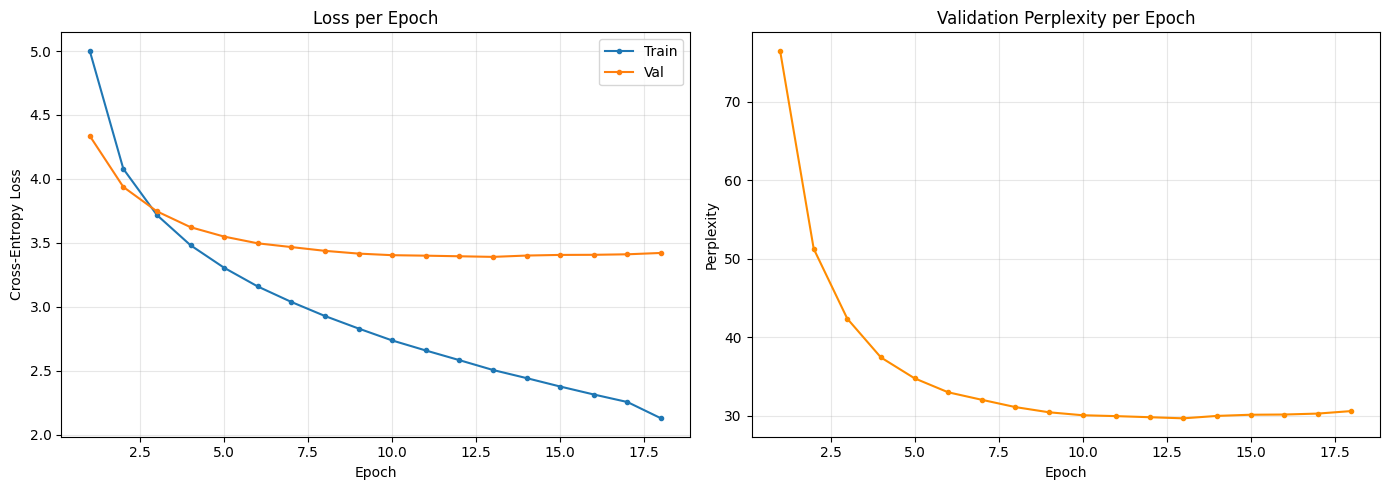

Plot saved → /content/drive/MyDrive/caption_data/trained/loss_curves.png


In [21]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', marker='o', markersize=3)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   marker='o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss per Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity
axes[1].plot(epochs_range, [math.exp(l) for l in history['val_loss']],
             color='darkorange', marker='o', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Validation Perplexity per Epoch')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, 'loss_curves.png')
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Plot saved → {plot_path}')

In [22]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

model.eval()
references = []
hypotheses = []

# Group val captions by image
val_grouped = df_val.groupby('image')['caption'].apply(list).reset_index()

with torch.no_grad():
    for _, row in tqdm(val_grouped.iterrows(), total=len(val_grouped), desc='BLEU eval'):
        img_path = os.path.join(IMAGES_DIR, row['image'])
        try:
            pil_img = Image.open(img_path).convert('RGB')
        except:
            continue

        img_tensor = val_transform(pil_img).to(DEVICE)
        caption    = model.caption_image(img_tensor, vocab, max_len=40)

        # References: list of tokenised human captions (excluding START/END)
        refs = [
            [w for w in c.split() if w not in (START_TOKEN, END_TOKEN)]
            for c in row['caption']
        ]
        hyp = caption.split()

        references.append(refs)
        hypotheses.append(hyp)

smoother = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=smoother)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0), smoothing_function=smoother)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)

print(f'BLEU-1: {bleu1:.4f}')
print(f'BLEU-2: {bleu2:.4f}')
print(f'BLEU-4: {bleu4:.4f}')

# Save to Drive
bleu_scores = {'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-4': bleu4}
with open(os.path.join(SAVE_DIR, 'bleu_scores.json'), 'w') as f:
    json.dump(bleu_scores, f, indent=2)
print('BLEU scores saved to Drive.')

BLEU eval:   0%|          | 0/1619 [00:00<?, ?it/s]

BLEU-1: 0.5352
BLEU-2: 0.3448
BLEU-4: 0.1389
BLEU scores saved to Drive.


## 14 · Qualitative Inference (Greedy Decoding)

Best checkpoint loaded (epoch 13, val_loss=3.3901)


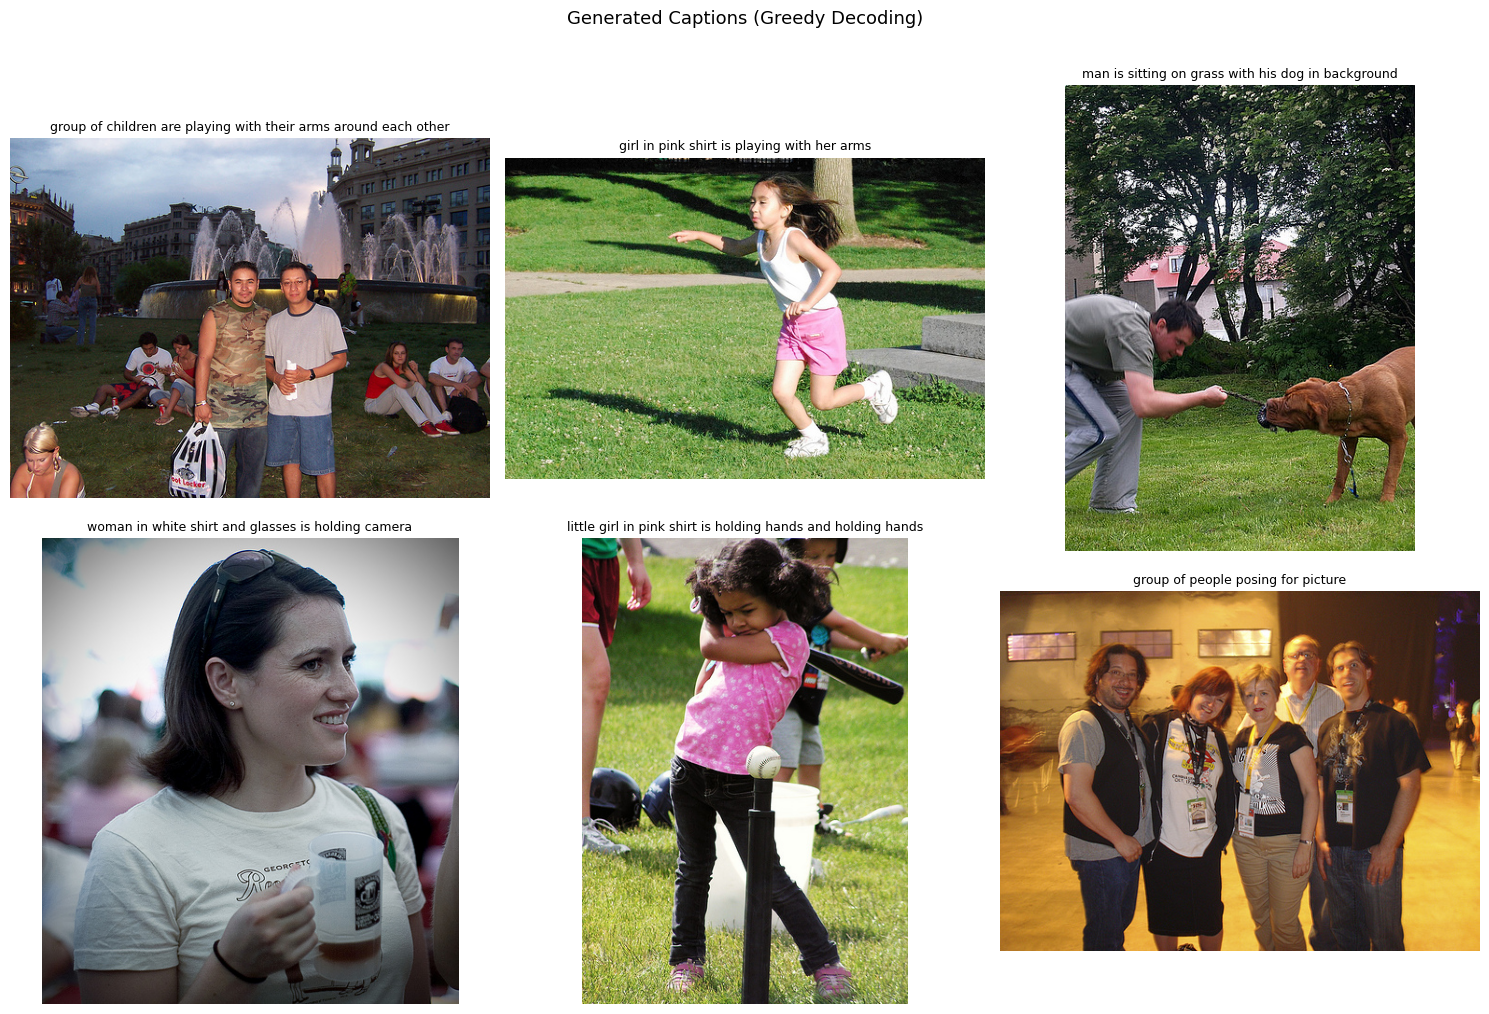

Sample captions saved → /content/drive/MyDrive/caption_data/trained/sample_captions.png


In [23]:
import matplotlib.pyplot as plt

# Load the best checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Best checkpoint loaded (epoch {checkpoint['epoch']}, "
      f"val_loss={checkpoint['val_loss']:.4f})")

# Sample 6 random validation images
sample_rows = df_val.drop_duplicates('image').sample(6, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = os.path.join(IMAGES_DIR, row['image'])
    try:
        pil_img = Image.open(img_path).convert('RGB')
    except (FileNotFoundError, OSError):
        pil_img = Image.new('RGB', (224, 224))

    img_tensor = val_transform(pil_img).to(DEVICE)
    caption    = model.caption_image(img_tensor, vocab, max_len=40)

    ax.imshow(pil_img)
    ax.set_title(caption, fontsize=9, wrap=True)
    ax.axis('off')

plt.suptitle('Generated Captions (Greedy Decoding)', fontsize=13, y=1.01)
plt.tight_layout()
inference_plot_path = os.path.join(SAVE_DIR, 'sample_captions.png')
plt.savefig(inference_plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Sample captions saved → {inference_plot_path}')